In [12]:
import pandas as pd
import datetime
import chess
from utils import display_fen, get_db_connection
import matplotlib.pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2

# create a personal database 
conn = get_db_connection(threads = 10)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import datetime

# Attach the primary database
try:
    conn.execute("ATTACH '/scratch/gpfs/GRIFFITHS/chess-db/lichess.db' AS core (READ_ONLY)")
except Exception as e:
    print(f"warning: {e}")

# Get games table
start_date = "2023-12-01"
end_date = "2023-12-02"

conn.sql(f"""CREATE OR REPLACE TABLE games AS SELECT * FROM core.games WHERE utc_datetime BETWEEN '{start_date}' AND '{end_date}'""")
games = conn.sql("""SELECT * FROM games""").df()

conn.sql("""
    CREATE OR REPLACE TABLE endgame_positions AS
    SELECT * FROM core.moves m
    JOIN games g ON m.gid = g.gid
    WHERE length(regexp_replace(m.board_position, '[^a-zA-Z]', '', 'g')) BETWEEN 6 AND 8
    AND g.initial_clock >= 300
    AND g.white_elo >= 2000
    AND g.black_elo >= 2000;
;""")
endgame_positions = conn.sql("""SELECT * FROM endgame_positions""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
from chess.engine import EngineTerminatedError
from tqdm import tqdm
from utils import get_stockfish_engine, evaluate_position
import numpy as np
SHALLOW_DEPTH = 1
DEEP_DEPTH = 15 

# Engine uses explicit NNUE paths + Threads=1, Hash=128 to reduce segfaults
engine = get_stockfish_engine()
engine.configure({"Threads": 1, "Hash": 128})


data = []
for i, position in tqdm(enumerate(endgame_positions.itertuples())):
    if i > 100:
        break
    
    board = chess.Board(position.board_position)
    try:
        player = 1 if board.turn == chess.WHITE else -1
        candidate_moves = set()  # move -> score at deep depth
        shallow_move = None

        with engine.analysis(board, chess.engine.Limit(depth=DEEP_DEPTH)) as analysis:
            for info in analysis:
                depth = info.get("depth")
                pv = info.get("pv")
                if pv:
                    if depth == SHALLOW_DEPTH:
                        shallow_move = pv[0]
                    candidate_moves.add(pv[0])

        if shallow_move is None or not candidate_moves: continue

        infos = engine.analyse(
            board,
            chess.engine.Limit(depth=DEEP_DEPTH),
            multipv=len(candidate_moves),
            root_moves=list(candidate_moves)
        )

        scores = {
            info["pv"][0]: info["score"].white().score(mate_score=10000) * player
            for info in infos
        }

        v_deep = max(scores.values()) 
        v_shallow = scores[shallow_move]
        voc = v_deep - v_shallow

        data.append(pd.Series(
            {
                "board_position": position.board_position,
                "player_white": position.player_white,
                "score_shallow": v_shallow,  
                "score_deep": v_deep,
                "voc": voc,
                "move_time": position.move_time,
            }
        ))

    except EngineTerminatedError:
        print("Engine crashed on position", position.board_position)
        try:
            engine.quit()
        except Exception:
            pass
        engine = get_stockfish_engine()
        engine.configure({"Threads": 1, "Hash": 128})


engine.quit()

101it [00:04, 23.70it/s]


In [42]:
df = pd.DataFrame(data)


(array([90.,  0.,  0.,  5.,  0.,  0.,  4.,  0.,  0.,  2.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

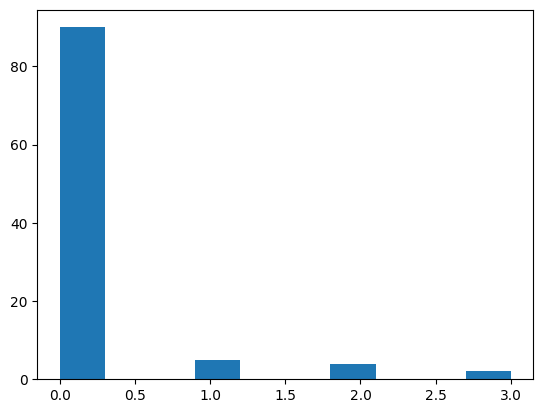

In [44]:
plt.hist(df.score_deep - df.score_shallow)
# plt.xlim(-30, 30)
# plt.ylim(-30, 30)

Correlation between VOC and move_time: 0.14816982651284588


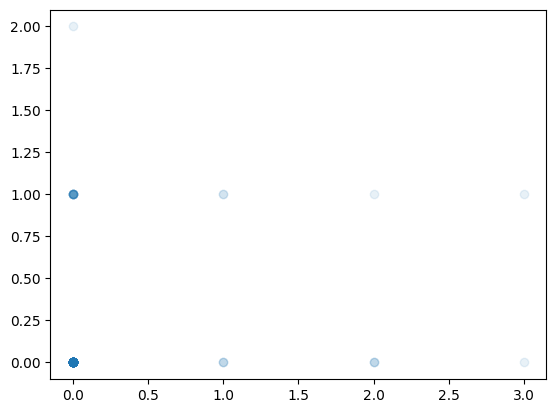

In [46]:
df = pd.DataFrame(data)

import matplotlib.pyplot as plt
plt.scatter(df.voc, df.move_time, alpha = 0.1)
correlation = df["voc"].corr(df["move_time"])
print("Correlation between VOC and move_time:", correlation)

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(games.n_moves, bins = 30)
ax.set(title = "Number of moves in games", xlabel = "Number of moves", ylabel = "Number of games")

fig, ax = plt.subplots(figsize=(4, 5))
games.opening.value_counts().sort_values()[lambda x: x > 80].plot(kind="barh", ax=ax)